[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/polsitoooo/Ingenieria-Del-Conocimiento/blob/main/Tareas_Ejercicios/Semana4/modelos_clasificacion_PolmarBrice%C3%B1o__I_resuelto(Dataset%20cancer%20Wisconsin).ipynb)

# Sesión 02 — Modelos de Clasificación
**Curso:** Ingeniería del Conocimiento (ISO56B)  
**Docente:** Msc. Jaime Antonio Huaytalla Pariona  
**Periodo:** 2026-II | Universidad Nacional del Centro del Perú  

---

## Objetivo
Implementar, comparar y analizar cuatro modelos fundamentales de clasificación supervisada — **Regresión Logística, Árbol de Decisión, SVM y KNN** — sobre el dataset **Wine Quality** de UCI, evaluando sus fortalezas, limitaciones y sensibilidad al preprocesamiento.

## 1. Configuración del entorno

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import (
    train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, RocCurveDisplay,
    accuracy_score, f1_score
)
from sklearn.inspection import DecisionBoundaryDisplay

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Entorno configurado correctamente.')

Entorno configurado correctamente.


---
## 2. Carga y comprensión del dataset

Utilizamos el **Wine Quality (Red)** del repositorio UCI Machine Learning. Contiene 1599 muestras de vino tinto portugués con 11 atributos fisicoquímicos y una puntuación de calidad (3–8).

Para construir un problema de **clasificación binaria**, definimos:
- **Clase 1 (Bueno):** calidad ≥ 7
- **Clase 0 (Estándar):** calidad < 7

Esta binarización genera un **problema desbalanceado**, lo que añade un reto realista al modelado.

In [2]:
# Carga directa desde UCI
URL = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

df = pd.read_csv(URL, sep=';')
print(f'Dataset cargado: {df.shape[0]} registros, {df.shape[1]} columnas')
df.head()

Dataset cargado: 1599 registros, 12 columnas


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


Distribución de calidad original:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


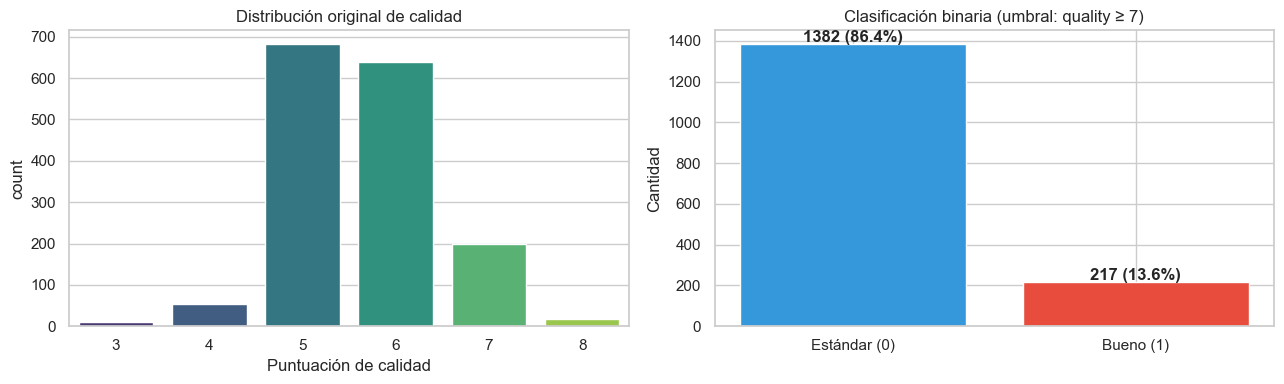


Ratio de desbalance: 6.4:1 (Estándar vs Bueno)


In [3]:
# Distribución original de la variable 'quality'
print('Distribución de calidad original:')
print(df['quality'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histograma original
sns.countplot(data=df, x='quality', ax=axes[0], palette='viridis')
axes[0].set_title('Distribución original de calidad')
axes[0].set_xlabel('Puntuación de calidad')

# Binarización
df['quality_label'] = (df['quality'] >= 7).astype(int)

counts = df['quality_label'].value_counts()
axes[1].bar(['Estándar (0)', 'Bueno (1)'], counts.values,
            color=['#3498db', '#e74c3c'])
for i, v in enumerate(counts.values):
    axes[1].text(i, v + 10, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Clasificación binaria (umbral: quality ≥ 7)')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()

print(f'\nRatio de desbalance: {counts[0]/counts[1]:.1f}:1 (Estándar vs Bueno)')

---
## 3. Análisis exploratorio orientado a clasificación

In [4]:
# 3.1  Estadísticas descriptivas por clase
features = df.columns.drop(['quality', 'quality_label'])

comparison = df.groupby('quality_label')[features].mean().T
comparison.columns = ['Estándar (0)', 'Bueno (1)']
comparison['Diferencia %'] = ((comparison['Bueno (1)'] - comparison['Estándar (0)']) / comparison['Estándar (0)'] * 100).round(1)
comparison.style.background_gradient(subset=['Diferencia %'], cmap='RdYlGn')

,Estándar (0),Bueno (1),Diferencia %
fixed acidity,8.236831,8.847005,7.400000
volatile acidity,0.547022,0.405530,-25.900000
citric acid,0.254407,0.376498,48.000000
residual sugar,2.512120,2.708756,7.800000
chlorides,0.089281,0.075912,-15.000000
free sulfur dioxide,16.172214,13.981567,-13.500000
total sulfur dioxide,48.285818,34.889401,-27.700000
density,0.996859,0.996030,-0.100000
pH,3.314616,3.288802,-0.800000
sulphates,0.644754,0.743456,15.300000


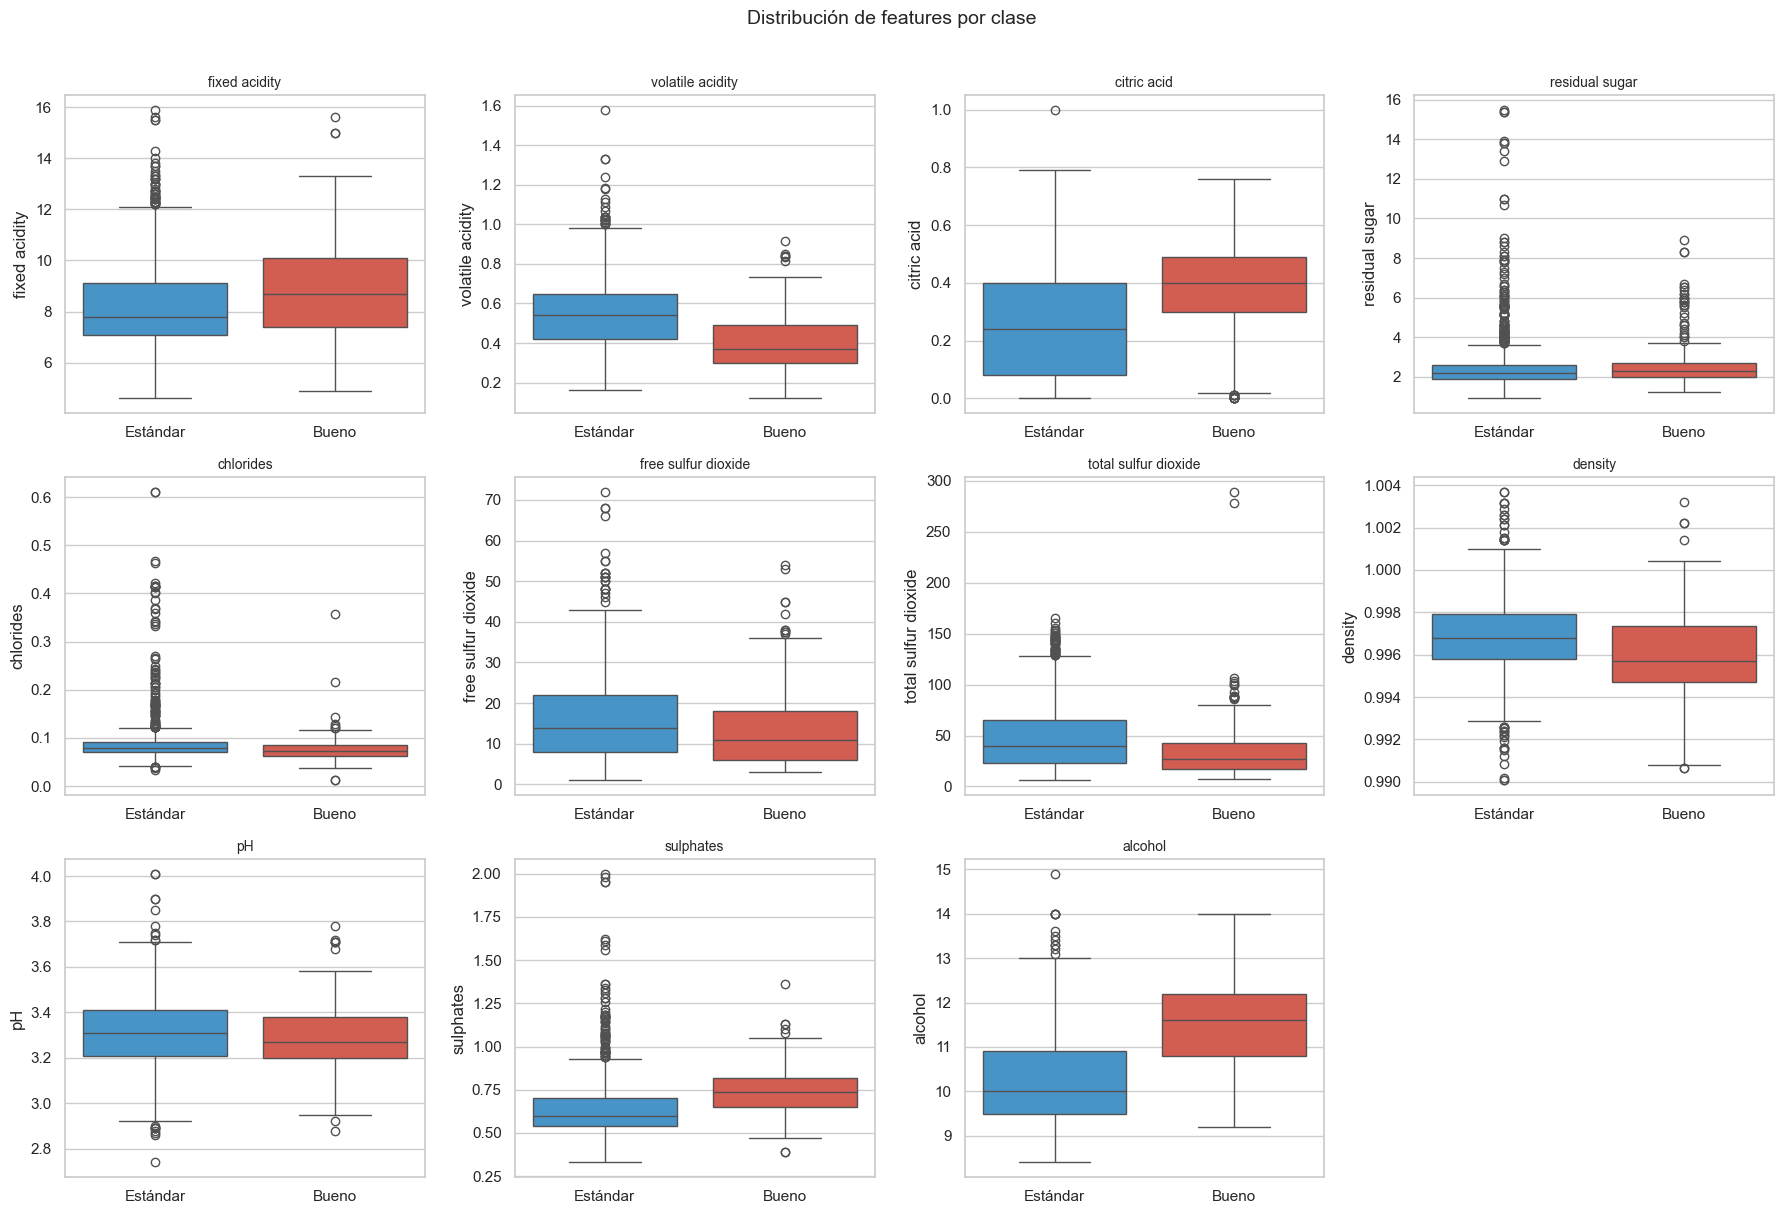

In [5]:
# 3.2  Distribución de features por clase (boxplots)
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.boxplot(data=df, x='quality_label', y=col, ax=axes[i],
                palette=['#3498db', '#e74c3c'], hue='quality_label', legend=False)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['Estándar', 'Bueno'])

# Ocultar subplot vacío
axes[-1].set_visible(False)
fig.suptitle('Distribución de features por clase', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

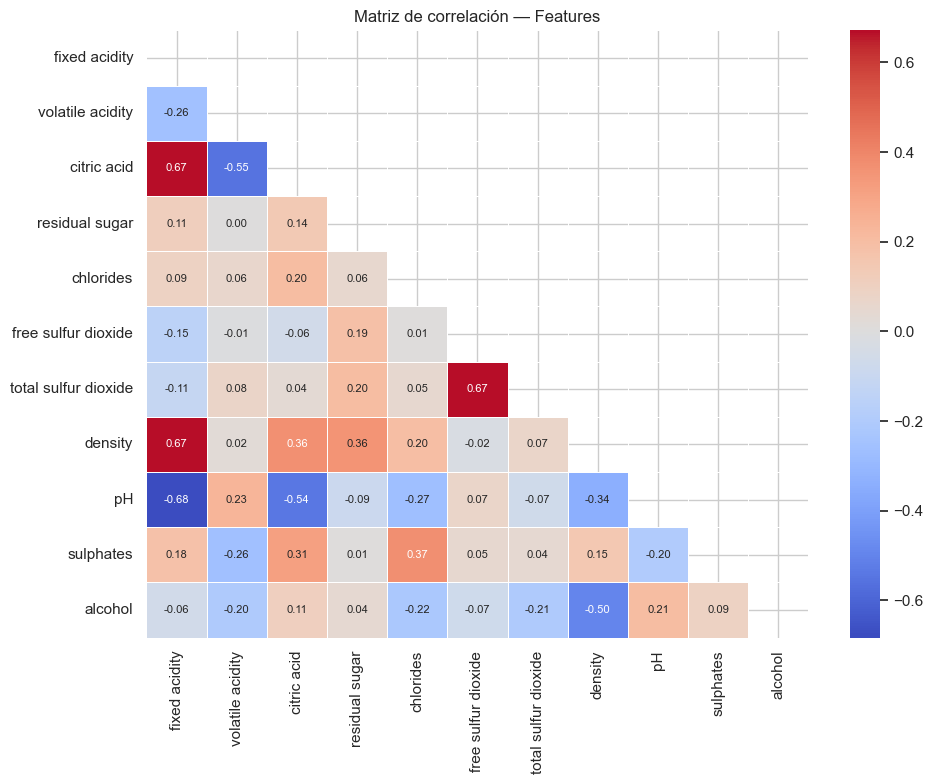

In [6]:
# 3.3  Correlación entre features
plt.figure(figsize=(10, 8))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Matriz de correlación — Features')
plt.tight_layout()
plt.show()

---
## 4. Preparación de datos

In [7]:
# 4.1  Separación features / target
X = df[features].copy()
y = df['quality_label'].copy()

# 4.2  Split estratificado 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape[0]} muestras  |  Test: {X_test.shape[0]} muestras')
print(f'Proporción clase 1 en train: {y_train.mean():.3f}')
print(f'Proporción clase 1 en test:  {y_test.mean():.3f}')

Train: 1279 muestras  |  Test: 320 muestras
Proporción clase 1 en train: 0.136
Proporción clase 1 en test:  0.134


In [8]:
# 4.3  Verificación de escalas (justifica la estandarización)
print('Rangos de las features (train):')
print('='*50)
for col in features:
    mn, mx = X_train[col].min(), X_train[col].max()
    print(f'{col:30s}  [{mn:8.2f}, {mx:8.2f}]  rango: {mx-mn:.2f}')

print('\n→ Las escalas difieren significativamente entre features.')
print('  Esto afecta directamente a SVM y KNN (basados en distancias).')
print('  Logistic Regression también se beneficia de la estandarización.')

Rangos de las features (train):
fixed acidity                   [    4.60,    15.90]  rango: 11.30
volatile acidity                [    0.12,     1.58]  rango: 1.46
citric acid                     [    0.00,     1.00]  rango: 1.00
residual sugar                  [    0.90,    15.50]  rango: 14.60
chlorides                       [    0.01,     0.61]  rango: 0.60
free sulfur dioxide             [    1.00,    72.00]  rango: 71.00
total sulfur dioxide            [    6.00,   165.00]  rango: 159.00
density                         [    0.99,     1.00]  rango: 0.01
pH                              [    2.74,     4.01]  rango: 1.27
sulphates                       [    0.33,     2.00]  rango: 1.67
alcohol                         [    8.40,    14.90]  rango: 6.50

→ Las escalas difieren significativamente entre features.
  Esto afecta directamente a SVM y KNN (basados en distancias).
  Logistic Regression también se beneficia de la estandarización.


---
## 5. Modelo 1 — Regresión Logística

**Fundamento:** Modelo lineal que estima la probabilidad de pertenencia a una clase mediante la función sigmoide. Ideal como **baseline** por su interpretabilidad y eficiencia.

In [9]:
# 5.1  Pipeline con estandarización
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                               class_weight='balanced'))  # Compensar desbalance
])

# Validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scores_lr = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring='f1')
print(f'Logistic Regression — F1 CV: {scores_lr.mean():.4f} ± {scores_lr.std():.4f}')

# Entrenamiento final
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)

Logistic Regression — F1 CV: 0.5045 ± 0.0355


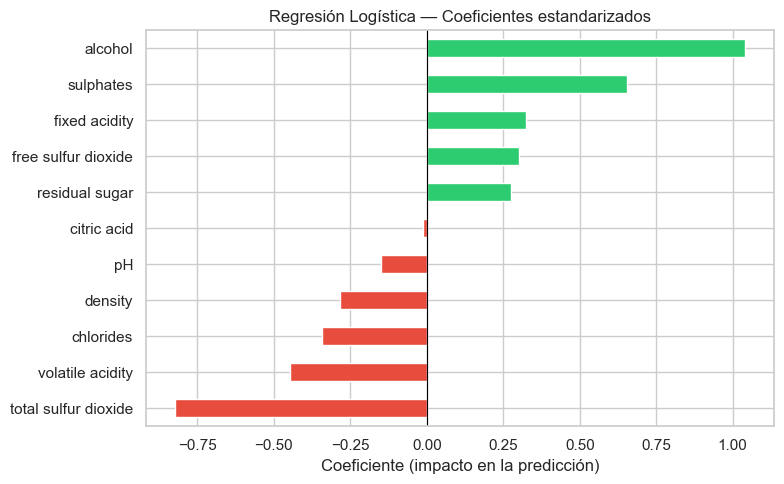


Interpretación: Un coeficiente positivo alto indica que valores mayores
de esa feature incrementan la probabilidad de clasificar como "Bueno".


In [10]:
# 5.2  Coeficientes del modelo (interpretabilidad)
coefs = pd.Series(
    pipe_lr.named_steps['clf'].coef_[0],
    index=features
).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in coefs.values]
coefs.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Regresión Logística — Coeficientes estandarizados')
ax.set_xlabel('Coeficiente (impacto en la predicción)')
ax.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

print('\nInterpretación: Un coeficiente positivo alto indica que valores mayores')
print('de esa feature incrementan la probabilidad de clasificar como "Bueno".')

---
## 6. Modelo 2 — Árbol de Decisión

**Fundamento:** Modelo no lineal que particiona el espacio de features mediante reglas if-else jerárquicas. Altamente interpretable, pero propenso al sobreajuste si no se controla la profundidad.

In [11]:
# 6.1  Pipeline (no requiere estandarización)
pipe_dt = Pipeline([
    ('clf', DecisionTreeClassifier(
        max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE
    ))
])

scores_dt = cross_val_score(pipe_dt, X_train, y_train, cv=cv, scoring='f1')
print(f'Decision Tree — F1 CV: {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')

pipe_dt.fit(X_train, y_train)
y_pred_dt = pipe_dt.predict(X_test)

Decision Tree — F1 CV: 0.5126 ± 0.0331


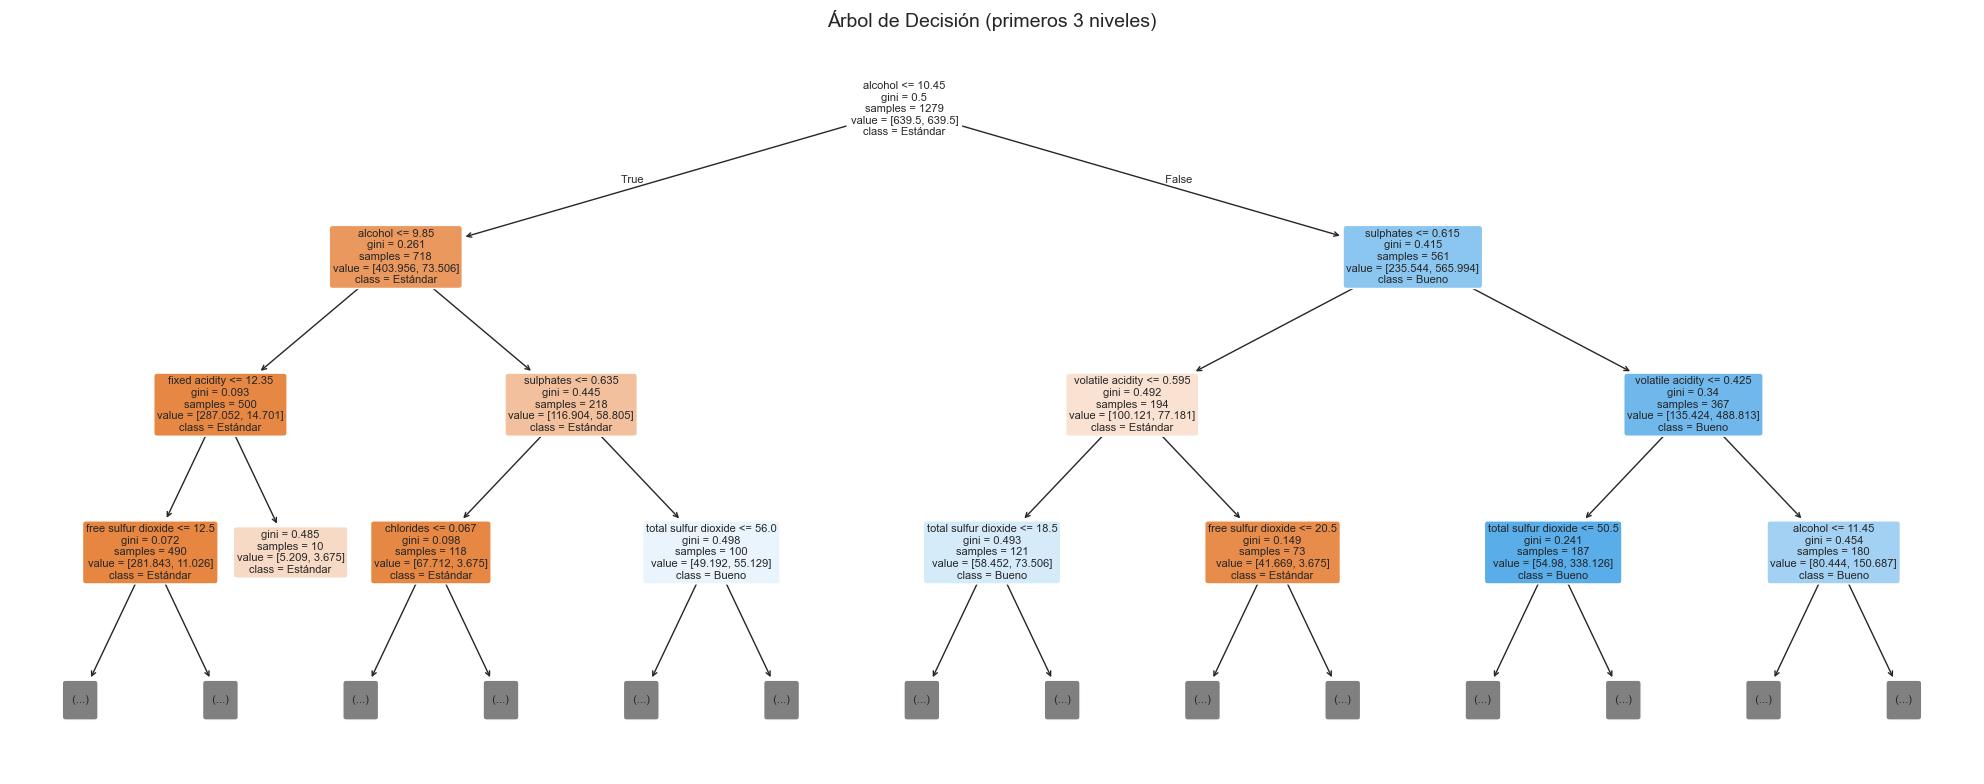

In [12]:
# 6.2  Visualización del árbol
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    pipe_dt.named_steps['clf'],
    feature_names=list(features),
    class_names=['Estándar', 'Bueno'],
    filled=True, rounded=True, fontsize=8, ax=ax,
    max_depth=3  # Mostrar solo 3 niveles para legibilidad
)
ax.set_title('Árbol de Decisión (primeros 3 niveles)', fontsize=14)
plt.tight_layout()
plt.show()

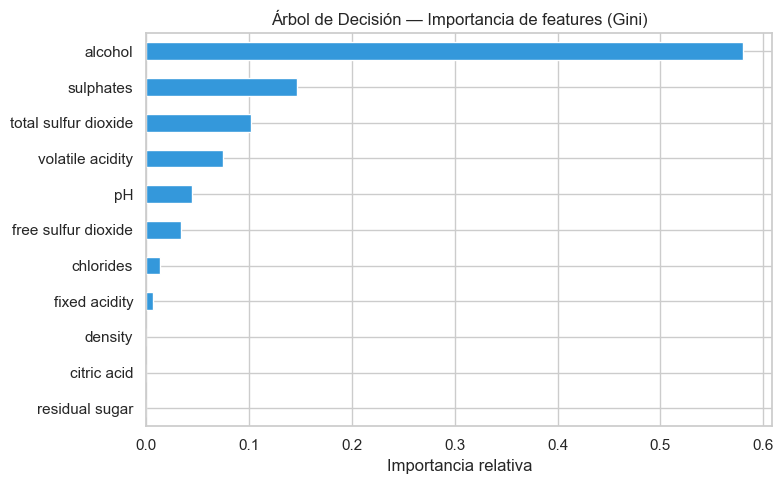

In [13]:
# 6.3  Importancia de features (Gini importance)
importances = pd.Series(
    pipe_dt.named_steps['clf'].feature_importances_,
    index=features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#3498db')
ax.set_title('Árbol de Decisión — Importancia de features (Gini)')
ax.set_xlabel('Importancia relativa')
plt.tight_layout()
plt.show()

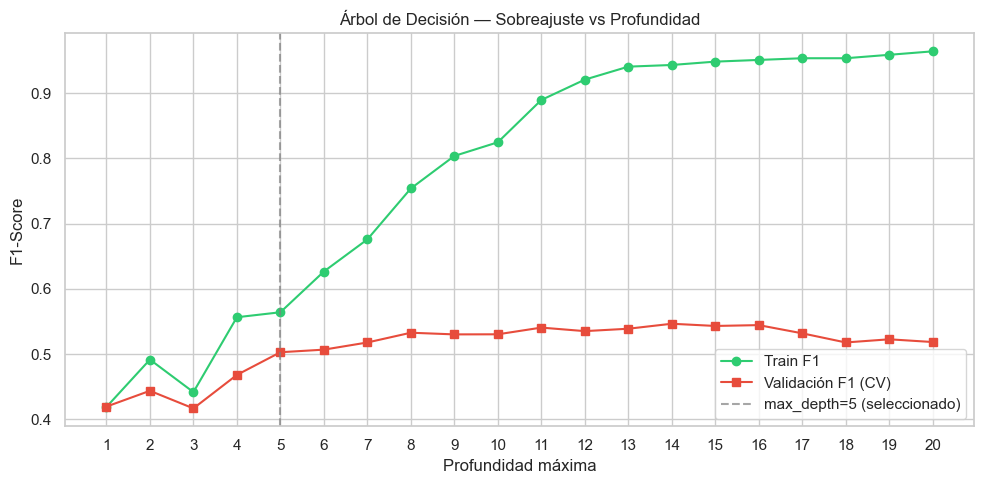

Observación: cuando la brecha entre train y validación crece,
el modelo está sobreajustando (memorizando el train set).


In [14]:
# 6.4  Efecto de la profundidad en sobreajuste/subajuste
depths = range(1, 21)
train_scores = []
val_scores = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, class_weight='balanced',
                                 random_state=RANDOM_STATE)
    dt.fit(X_train, y_train)
    train_scores.append(f1_score(y_train, dt.predict(X_train)))
    cv_s = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')
    val_scores.append(cv_s.mean())

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_scores, 'o-', label='Train F1', color='#2ecc71')
ax.plot(depths, val_scores, 's-', label='Validación F1 (CV)', color='#e74c3c')
ax.axvline(x=5, color='gray', linestyle='--', alpha=0.7, label='max_depth=5 (seleccionado)')
ax.set_xlabel('Profundidad máxima')
ax.set_ylabel('F1-Score')
ax.set_title('Árbol de Decisión — Sobreajuste vs Profundidad')
ax.legend()
ax.set_xticks(depths)
plt.tight_layout()
plt.show()

print('Observación: cuando la brecha entre train y validación crece,')
print('el modelo está sobreajustando (memorizando el train set).')

---
## 7. Modelo 3 — Support Vector Machine (SVM)

**Fundamento:** Busca el hiperplano que maximiza el margen de separación entre clases. Con funciones kernel puede manejar fronteras no lineales. Es **sensible a la escala** de las features.

In [15]:
# 7.1  Comparación de kernels
kernels = ['linear', 'rbf', 'poly']
svm_results = {}

for kernel in kernels:
    pipe_svm = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel=kernel, class_weight='balanced',
                     random_state=RANDOM_STATE, probability=True))
    ])
    scores = cross_val_score(pipe_svm, X_train, y_train, cv=cv, scoring='f1')
    svm_results[kernel] = scores
    print(f'SVM ({kernel:6s}) — F1 CV: {scores.mean():.4f} ± {scores.std():.4f}')

# Seleccionar el mejor kernel
best_kernel = max(svm_results, key=lambda k: svm_results[k].mean())
print(f'\nMejor kernel: {best_kernel}')

SVM (linear) — F1 CV: 0.4982 ± 0.0237
SVM (rbf   ) — F1 CV: 0.5246 ± 0.0427
SVM (poly  ) — F1 CV: 0.5355 ± 0.0258

Mejor kernel: poly


In [16]:
# 7.2  Entrenamiento con el mejor kernel
pipe_svm = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(kernel=best_kernel, class_weight='balanced',
                 random_state=RANDOM_STATE, probability=True))
])

pipe_svm.fit(X_train, y_train)
y_pred_svm = pipe_svm.predict(X_test)
scores_svm = svm_results[best_kernel]

In [17]:
# 7.3  Impacto de la estandarización en SVM
# SVM SIN estandarizar
svm_no_scale = SVC(kernel=best_kernel, class_weight='balanced',
                    random_state=RANDOM_STATE)
scores_no_scale = cross_val_score(svm_no_scale, X_train, y_train, cv=cv, scoring='f1')

print('Impacto de la estandarización en SVM:')
print(f'  CON StandardScaler: F1 = {scores_svm.mean():.4f}')
print(f'  SIN StandardScaler: F1 = {scores_no_scale.mean():.4f}')
print(f'  Diferencia: {(scores_svm.mean() - scores_no_scale.mean())*100:+.2f} puntos porcentuales')
print('\n→ La estandarización es CRÍTICA para modelos basados en distancias.')

Impacto de la estandarización en SVM:
  CON StandardScaler: F1 = 0.5355
  SIN StandardScaler: F1 = 0.2832
  Diferencia: +25.23 puntos porcentuales

→ La estandarización es CRÍTICA para modelos basados en distancias.


---
## 8. Modelo 4 — K-Nearest Neighbors (KNN)

**Fundamento:** Clasifica según la mayoría de votos de los K vecinos más cercanos. No paramétrico, sensible a la escala y a la dimensionalidad. El valor de K controla el trade-off bias-varianza.

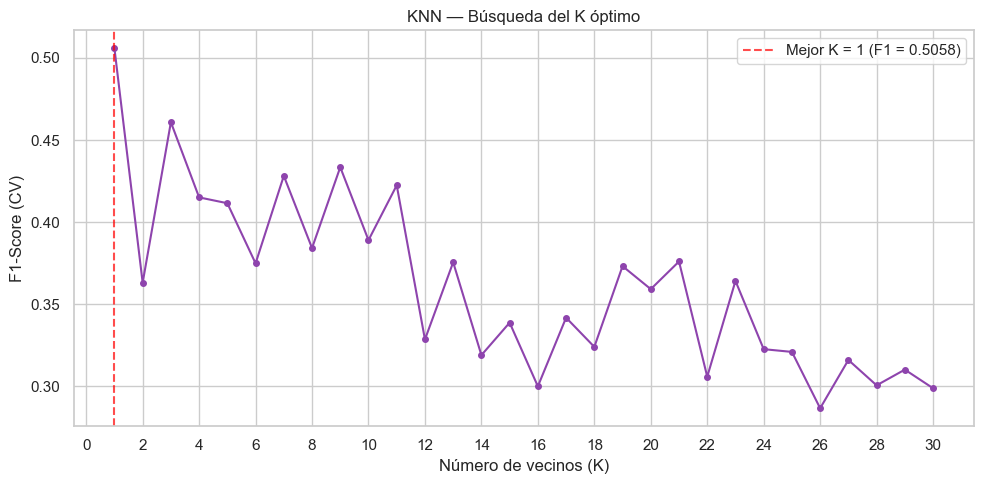

K óptimo: 1


In [18]:
# 8.1  Búsqueda del K óptimo
k_range = range(1, 31)
k_scores = []

for k in k_range:
    pipe_knn = Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
    k_scores.append(scores.mean())

best_k = k_range[np.argmax(k_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(k_range, k_scores, 'o-', markersize=4, color='#8e44ad')
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7,
           label=f'Mejor K = {best_k} (F1 = {max(k_scores):.4f})')
ax.set_xlabel('Número de vecinos (K)')
ax.set_ylabel('F1-Score (CV)')
ax.set_title('KNN — Búsqueda del K óptimo')
ax.legend()
ax.set_xticks(range(0, 31, 2))
plt.tight_layout()
plt.show()

print(f'K óptimo: {best_k}')

In [19]:
# 8.2  Entrenamiento con K óptimo
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier(n_neighbors=best_k))
])

scores_knn = cross_val_score(pipe_knn, X_train, y_train, cv=cv, scoring='f1')
print(f'KNN (K={best_k}) — F1 CV: {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')

pipe_knn.fit(X_train, y_train)
y_pred_knn = pipe_knn.predict(X_test)

KNN (K=1) — F1 CV: 0.5058 ± 0.0254


---
## 9. Análisis comparativo de modelos

In [20]:
# 9.1  Tabla resumen
models = {
    'Logistic Regression': (pipe_lr, y_pred_lr, scores_lr),
    'Decision Tree':       (pipe_dt, y_pred_dt, scores_dt),
    f'SVM ({best_kernel})': (pipe_svm, y_pred_svm, scores_svm),
    f'KNN (K={best_k})':   (pipe_knn, y_pred_knn, scores_knn)
}

summary = []
for name, (pipe, y_pred, cv_scores) in models.items():
    summary.append({
        'Modelo': name,
        'F1 CV (mean)': f'{cv_scores.mean():.4f}',
        'F1 CV (std)': f'{cv_scores.std():.4f}',
        'Accuracy Test': f'{accuracy_score(y_test, y_pred):.4f}',
        'F1 Test': f'{f1_score(y_test, y_pred):.4f}'
    })

summary_df = pd.DataFrame(summary)
print('='*80)
print('COMPARACIÓN DE MODELOS')
print('='*80)
summary_df

COMPARACIÓN DE MODELOS


,Modelo,F1 CV (mean),F1 CV (std),Accuracy Test,F1 Test
0,Logistic Regression,0.5045,0.0355,0.8125,0.5312
1,Decision Tree,0.5126,0.0331,0.8094,0.5414
2,SVM (poly),0.5355,0.0258,0.8969,0.6598
3,KNN (K=1),0.5058,0.0254,0.9094,0.6588


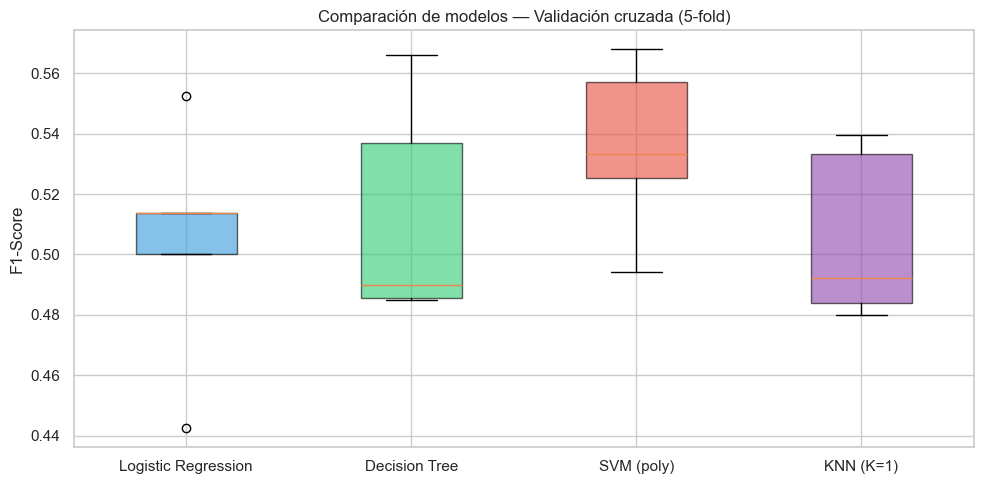

In [21]:
# 9.2  Boxplot comparativo de validación cruzada
fig, ax = plt.subplots(figsize=(10, 5))
cv_data = [scores_lr, scores_dt, scores_svm, scores_knn]
labels = list(models.keys())
bp = ax.boxplot(cv_data, tick_labels=labels, patch_artist=True)
colors_box = ['#3498db', '#2ecc71', '#e74c3c', '#8e44ad']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel('F1-Score')
ax.set_title('Comparación de modelos — Validación cruzada (5-fold)')
plt.tight_layout()
plt.show()

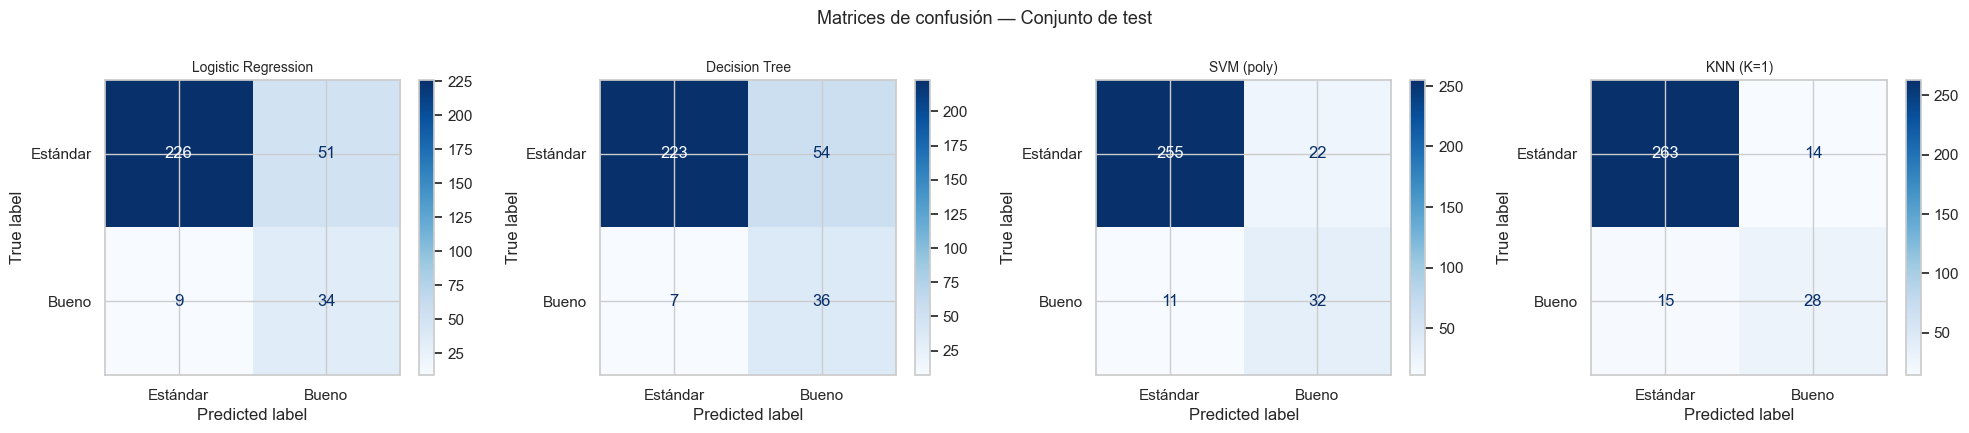

In [22]:
# 9.3  Matrices de confusión comparativas
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, (pipe, y_pred, _)) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Estándar', 'Bueno'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name, fontsize=10)

fig.suptitle('Matrices de confusión — Conjunto de test', fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

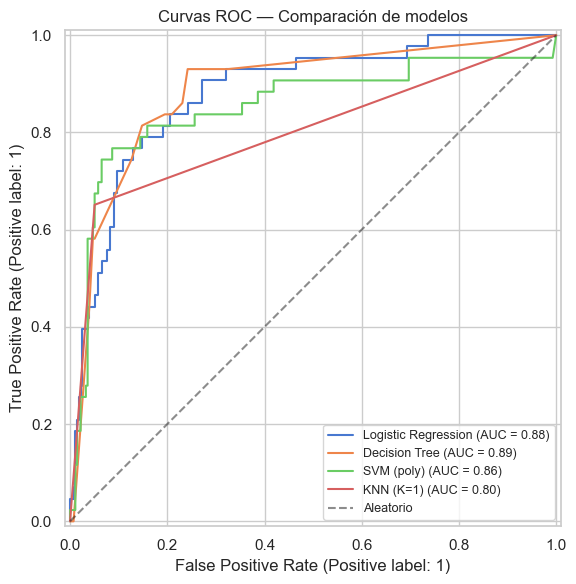

In [23]:
# 9.4  Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(7, 6))

for name, (pipe, _, _) in models.items():
    RocCurveDisplay.from_estimator(pipe, X_test, y_test, ax=ax, name=name)

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Aleatorio')
ax.set_title('Curvas ROC — Comparación de modelos')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [24]:
# 9.5  Classification report detallado del mejor modelo
best_model_name = max(models, key=lambda k: float(models[k][2].mean()))
best_pipe, best_pred, best_cv = models[best_model_name]

print(f'\nMejor modelo: {best_model_name}')
print('='*60)
print(classification_report(y_test, best_pred,
                             target_names=['Estándar', 'Bueno']))


Mejor modelo: SVM (poly)
              precision    recall  f1-score   support

    Estándar       0.96      0.92      0.94       277
       Bueno       0.59      0.74      0.66        43

    accuracy                           0.90       320
   macro avg       0.78      0.83      0.80       320
weighted avg       0.91      0.90      0.90       320



---
## 10. Resumen comparativo

| Modelo | Fortalezas | Limitaciones | ¿Cuándo usarlo? |
|---|---|---|---|
| **Regresión Logística** | Rápido, interpretable (coeficientes), probabilístico | Asume relación lineal entre features y log-odds | Baseline; cuando la interpretabilidad es prioritaria |
| **Árbol de Decisión** | Interpretable (visualización), maneja no linealidades, no requiere estandarización | Propenso a sobreajuste; inestable (pequeños cambios en datos alteran el árbol) | Cuando se necesitan reglas explicables; como parte de ensambles |
| **SVM** | Efectivo en alta dimensionalidad; flexible con kernels | Sensible a la escala; costoso en datasets grandes; difícil de interpretar | Datasets de tamaño moderado con fronteras complejas |
| **KNN** | Simple, no paramétrico, adaptable | Lento en predicción (distancias contra todo el train); sensible a escala y dimensionalidad | Datasets pequeños-medianos; cuando la frontera es irregular |

---
## 11. Ejercicios propuestos

### Ejercicio 1 — GridSearchCV para SVM
Realice una búsqueda de hiperparámetros para SVM usando `GridSearchCV` con la siguiente grilla:
- `C`: [0.1, 1, 10, 100]
- `gamma`: ['scale', 'auto', 0.01, 0.1]
- `kernel`: ['rbf', 'poly']

Reporte los mejores hiperparámetros, el F1-score obtenido y compare contra el SVM base de la sesión.

### Ejercicio 2 — Clasificación multiclase
En lugar de binarizar la variable `quality`, utilice las clases originales (3–8) y entrene los 4 modelos. Analice:
- ¿Cómo cambia el rendimiento de cada modelo?
- ¿Qué clases son más difíciles de distinguir?
- ¿Qué métrica de F1 es más adecuada: `macro`, `micro` o `weighted`? Justifique.

### Ejercicio 3 — Aplicación con dataset propio
Seleccione un dataset de clasificación de su interés (puede ser de Kaggle, UCI, o datos propios). Debe tener al menos 500 registros y 5 features. Aplique los 4 modelos de clasificación, realice el análisis comparativo completo y documente sus hallazgos.

---
*Ingeniería del Conocimiento (ISO56B) — UNCP — 2026-II*

---
# Solución de ejercicios propuestos
Las soluciones se agregan después del contenido original para conservar su estructura y recursos.


---
# Solución — Ejercicio 1: GridSearchCV para SVM


In [25]:
# Se reutilizan X_train, y_train y cv definidos en la sesión.
from sklearn.model_selection import GridSearchCV

pipe_svm_grid = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', SVC(class_weight='balanced', probability=True,
                random_state=RANDOM_STATE))
])
param_grid = {
    'clf__C': [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 'auto', 0.01, 0.1],
    'clf__kernel': ['rbf', 'poly']
}
grid = GridSearchCV(pipe_svm_grid, param_grid, scoring='f1',
                    cv=cv, n_jobs=-1, refit=True)
grid.fit(X_train, y_train)
y_pred_grid = grid.predict(X_test)

print("Mejores hiperparámetros:", grid.best_params_)
print(f"Mejor F1 promedio CV: {grid.best_score_:.4f}")
print(f"F1 test SVM optimizado: {f1_score(y_test, y_pred_grid):.4f}")
print(f"F1 CV SVM base: {scores_svm.mean():.4f}")
print(f"F1 test SVM base: {f1_score(y_test, y_pred_svm):.4f}")
print("\nComparación: la diferencia de F1 test (optimizado - base) es:",
      f"{f1_score(y_test, y_pred_grid)-f1_score(y_test, y_pred_svm):+.4f}")


Mejores hiperparámetros: {'clf__C': 10, 'clf__gamma': 0.1, 'clf__kernel': 'rbf'}
Mejor F1 promedio CV: 0.5450
F1 test SVM optimizado: 0.6422
F1 CV SVM base: 0.5355
F1 test SVM base: 0.6598

Comparación: la diferencia de F1 test (optimizado - base) es: -0.0176


**Interpretación:** `GridSearchCV` evalúa las 32 combinaciones (4 valores de C × 4 de gamma × 2 kernels) mediante validación cruzada estratificada de cinco particiones. `best_params_` identifica la combinación con mayor F1 medio en validación; el F1 del conjunto de prueba se informa aparte y no interviene en la selección. Una diferencia positiva en test indica mejora observada en esta partición, no una garantía de generalización.


---
# Solución — Ejercicio 2: Clasificación multiclase


In [26]:
# Se predicen las categorías originales de quality (sin binarizar).
X_multi = df.drop(columns=['quality', 'quality_label'], errors='ignore').copy()
# Para el dataset Wine Quality original, quality es la etiqueta.
if 'quality' not in df.columns:
    raise ValueError("Este ejercicio requiere el dataset Wine Quality original.")
y_multi = df['quality'].copy()
Xm_train, Xm_test, ym_train, ym_test = train_test_split(
    X_multi, y_multi, test_size=0.20, random_state=RANDOM_STATE,
    stratify=y_multi
)
models_multi = {
    'Regresión logística': Pipeline([('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                                   random_state=RANDOM_STATE))]),
    'Árbol de decisión': DecisionTreeClassifier(max_depth=5, min_samples_leaf=10,
        class_weight='balanced', random_state=RANDOM_STATE),
    'SVM': Pipeline([('scaler', StandardScaler()),
        ('clf', SVC(class_weight='balanced', random_state=RANDOM_STATE))]),
    'KNN': Pipeline([('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=best_k))])
}
multi_rows=[]
multi_preds={}
for name, model in models_multi.items():
    model.fit(Xm_train, ym_train)
    pred=model.predict(Xm_test)
    multi_preds[name]=pred
    multi_rows.append({
        'Modelo':name,
        'Accuracy':accuracy_score(ym_test,pred),
        'F1 macro':f1_score(ym_test,pred,average='macro',zero_division=0),
        'F1 micro':f1_score(ym_test,pred,average='micro',zero_division=0),
        'F1 weighted':f1_score(ym_test,pred,average='weighted',zero_division=0)
    })
multi_results=pd.DataFrame(multi_rows).set_index('Modelo')
display(multi_results.round(4))


,Accuracy,F1 macro,F1 micro,F1 weighted
Modelo,,,,
Regresión logística,0.3969,0.2402,0.3969,0.4408
Árbol de decisión,0.3969,0.2702,0.3969,0.4089
SVM,0.4594,0.2754,0.4594,0.4918
KNN,0.6250,0.3762,0.6250,0.6296


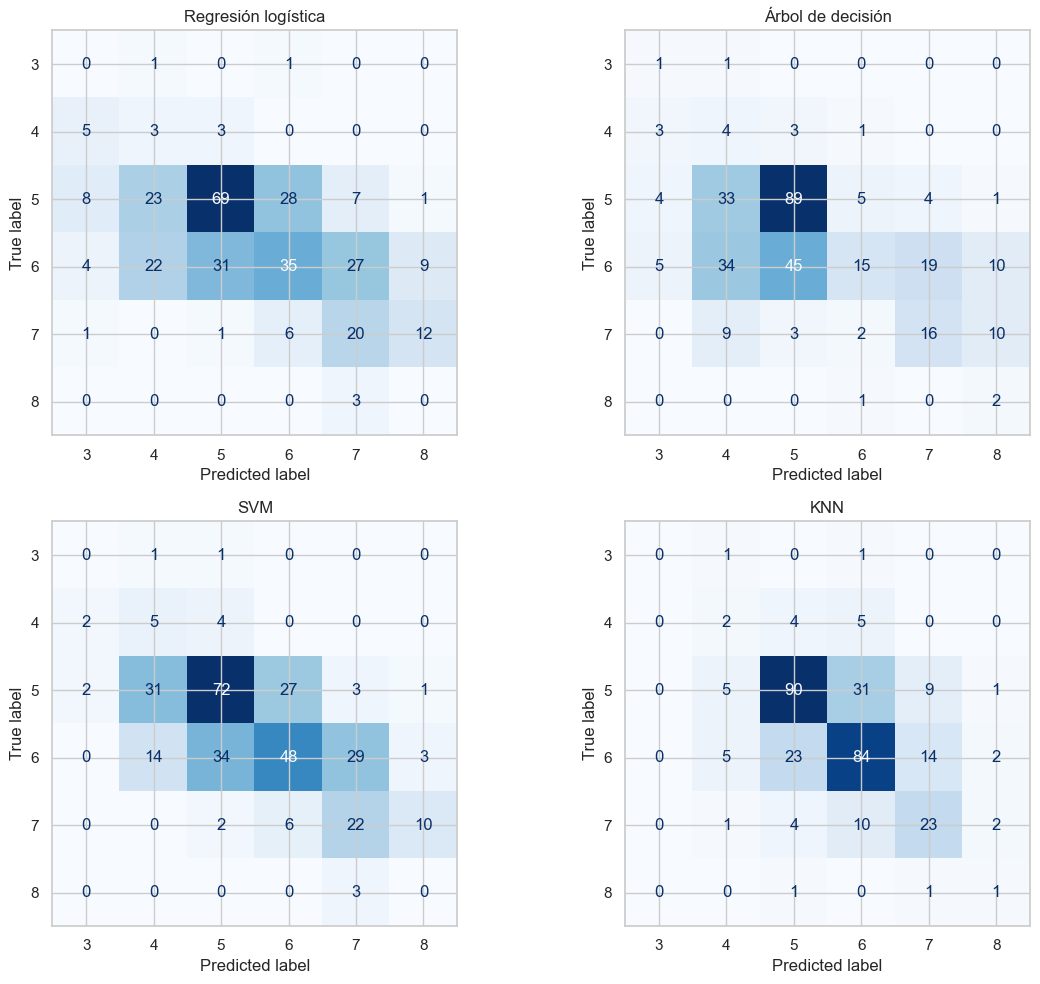


 Regresión logística
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.06      0.27      0.10        11
           5       0.66      0.51      0.57       136
           6       0.50      0.27      0.35       128
           7       0.35      0.50      0.41        40
           8       0.00      0.00      0.00         3

    accuracy                           0.40       320
   macro avg       0.26      0.26      0.24       320
weighted avg       0.53      0.40      0.44       320


 Árbol de decisión
              precision    recall  f1-score   support

           3       0.08      0.50      0.13         2
           4       0.05      0.36      0.09        11
           5       0.64      0.65      0.64       136
           6       0.62      0.12      0.20       128
           7       0.41      0.40      0.41        40
           8       0.09      0.67      0.15         3

    accuracy                       

In [27]:
# Reporte por clase y matrices de confusión para observar clases difíciles.
from sklearn.metrics import ConfusionMatrixDisplay
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, (name, pred) in zip(axes.flatten(), multi_preds.items()):
    ConfusionMatrixDisplay.from_predictions(ym_test, pred, ax=ax,
        cmap='Blues', colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()
for name, pred in multi_preds.items():
    print("\n", name)
    print(classification_report(ym_test, pred, zero_division=0))


**Análisis:** al pasar de dos grupos a las puntuaciones originales, el problema exige distinguir varias clases, algunas con pocas observaciones y puntuaciones cercanas. La matriz de confusión y el recall por clase permiten identificar qué puntuaciones se confunden; no se debe asumir de antemano cuáles son las más difíciles, sino leerlo en los resultados ejecutados. `macro` da el mismo peso a cada clase y es útil para evaluar clases minoritarias; `micro` agrega aciertos globales y en clasificación multiclase de etiqueta única coincide con accuracy; `weighted` pondera cada clase por su soporte y refleja el desempeño considerando el desbalance. Para valorar todas las clases con igual importancia, se recomienda reportar F1-macro junto con F1-weighted.


---
# Solución — Ejercicio 3: Aplicación con dataset propio (Mushrooms)
**Base utilizada:** `mushrooms.csv` (8 124 registros, 22 características categóricas y variable objetivo `class`). Se clasificará el hongo como comestible (`e`) o venenoso (`p`). El conjunto supera los mínimos solicitados de 500 registros y 5 features. No se interpretará el modelo como una autorización para consumir hongos.


## 1. Carga y comprensión del dataset


In [28]:
# Carga robusta: funciona en Colab (archivo subido) o carpeta local.
import os
ruta = 'mushrooms.csv'
if not os.path.exists(ruta) and os.path.exists('/mnt/data/mushrooms.csv'):
    ruta = '/mnt/data/mushrooms.csv'
df_m = pd.read_csv(ruta)
print("Archivo:", ruta, "| Dimensiones:", df_m.shape)
display(df_m.head(8))
display(df_m.describe(include='all').T.head(22))
print("\\nTipos de datos:\\n", df_m.dtypes.value_counts())
print("\\nDistribución de la variable objetivo:")
display(df_m['class'].value_counts().rename(index={'e':'Comestible','p':'Venenoso'}))


Dimensiones: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g



Tipos de datos:
 object    23
Name: count, dtype: int64

Clases:
 class
e    4208
p    3916
Name: count, dtype: int64


## 2. Análisis exploratorio


Valores faltantes por columna:


class              0
cap-shape          0
cap-surface        0
cap-color          0
bruises            0
odor               0
gill-attachment    0
gill-spacing       0
gill-size          0
gill-color         0
dtype: int64

Duplicados: 0


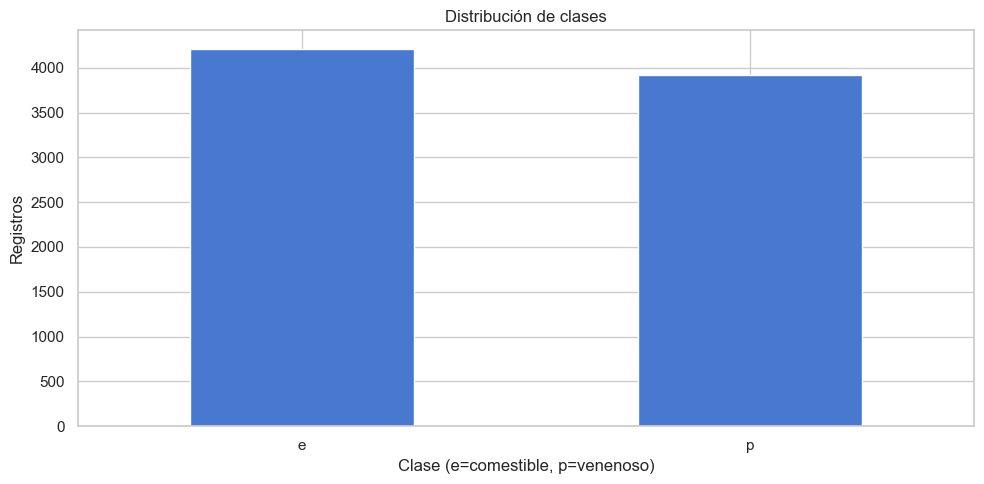

In [29]:
print("Valores faltantes por columna:")
display(df_m.isna().sum().sort_values(ascending=False).head(10))
print("Duplicados:", df_m.duplicated().sum())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
df_m['class'].value_counts().reindex(['e','p']).plot(kind='bar', ax=axes[0])
axes[0].set_title('Distribución de la clase objetivo')
axes[0].set_xlabel('Clase (e=comestible, p=venenoso)'); axes[0].set_ylabel('Cantidad')
# Frecuencias de categorías para algunas variables representativas
cols_plot = [c for c in ['cap-shape','cap-color','odor','gill-color'] if c in df_m.columns]
if cols_plot:
    df_m[cols_plot[0]].value_counts().plot(kind='bar', ax=axes[1])
    axes[1].set_title(f'Distribución de categorías: {cols_plot[0]}')
    axes[1].set_xlabel(cols_plot[0]); axes[1].set_ylabel('Cantidad')
plt.tight_layout(); plt.show()

missing=df_m.isna().sum()
if missing.sum()==0:
    print("No se observan valores faltantes.")
else:
    missing[missing>0].plot(kind='bar',title='Valores faltantes por variable')
    plt.tight_layout(); plt.show()


## 3. Preparación de datos
Se separa la variable objetivo y se codifican las categorías con One-Hot Encoding dentro de un pipeline. Así, el codificador se ajusta solo con los datos de entrenamiento, evitando fuga de información. La división es estratificada 80/20.


In [30]:
X_m=df_m.drop(columns='class')
y_m=df_m['class'].map({'e':0,'p':1})
Xm_train, Xm_test, ym_train, ym_test=train_test_split(
    X_m,y_m,test_size=0.20,random_state=RANDOM_STATE,stratify=y_m)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
cat_cols=Xm_train.columns.tolist()
prep=ColumnTransformer([('cat',OneHotEncoder(handle_unknown='ignore'),
                         cat_cols)])
print("Train:",Xm_train.shape," Test:",Xm_test.shape)
print("Features originales:",len(cat_cols))
fig,ax=plt.subplots(figsize=(7,4))
pd.DataFrame({'Entrenamiento':ym_train.value_counts(normalize=True),
              'Prueba':ym_test.value_counts(normalize=True)}).rename(
    index={0:'Comestible',1:'Venenoso'}).plot(kind='bar',ax=ax)
ax.set_title('Proporción de clases en train y test'); ax.set_ylabel('Proporción')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()


Train: (6499, 22)  Test: (1625, 22)
Proporción venenosos train/test: 0.482 0.482


## 4. Modelo 1 — Regresión logística


In [31]:
m_lr=Pipeline([('prep',prep),('scaler',StandardScaler(with_mean=False)),
    ('clf',LogisticRegression(max_iter=2000,class_weight='balanced',
                              random_state=RANDOM_STATE))])
print("Pipeline de Regresión Logística listo:")
display(m_lr)


## 5. Modelo 2 — Árbol de decisión


In [32]:
m_dt=Pipeline([('prep',prep),('clf',DecisionTreeClassifier(
    max_depth=8,min_samples_leaf=5,class_weight='balanced',
    random_state=RANDOM_STATE))])
print("Pipeline de Árbol de Decisión listo:")
display(m_dt)


## 6. Modelo 3 — Support Vector Machine (SVM)


In [33]:
m_svm=Pipeline([('prep',prep),('scaler',StandardScaler(with_mean=False)),
    ('clf',SVC(kernel='rbf',class_weight='balanced',random_state=RANDOM_STATE))])
print("Pipeline SVM con kernel RBF listo:")
display(m_svm)


## 7. Modelo 4 — K-Nearest Neighbors (KNN)


In [37]:
m_knn=Pipeline([('prep',prep),('scaler',StandardScaler(with_mean=False)),
    ('clf',KNeighborsClassifier(n_neighbors=5))])
print("Pipeline KNN (5 vecinos) listo:")
display(m_knn)


## 8. Entrenamiento y validación
Se utiliza F1 para la clase venenosa (1), porque interesa medir conjuntamente la precisión y la exhaustividad al detectar esa clase. La validación cruzada se ejecuta sobre entrenamiento; la prueba queda reservada para la evaluación final.


In [35]:
models_m={'Regresión logística':m_lr,'Árbol de decisión':m_dt,
           'SVM (RBF)':m_svm,'KNN (K=5)':m_knn}
cv_m=StratifiedKFold(n_splits=5,shuffle=True,random_state=RANDOM_STATE)
scores_m={}
preds_m={}
for name,model in models_m.items():
    sc=cross_val_score(model,Xm_train,ym_train,cv=cv_m,scoring='f1',
                       n_jobs=-1)
    model.fit(Xm_train,ym_train)
    scores_m[name]=sc
    preds_m[name]=model.predict(Xm_test)
    print(f"{name}: F1 CV={sc.mean():.4f} ± {sc.std():.4f}")


Regresión logística: F1 CV=0.9997 ± 0.0006
Árbol de decisión: F1 CV=0.9987 ± 0.0016
SVM (RBF): F1 CV=0.9995 ± 0.0010
KNN (K=5): F1 CV=0.9994 ± 0.0013


## 9. Análisis comparativo completo y gráficos


,F1 CV medio,Desv. estándar CV,Accuracy test,Precision venenoso,Recall venenoso,F1 venenoso test
Modelo,,,,,,
Regresión logística,0.9997,0.0006,1.0000,1.0,1.0000,1.0000
Árbol de decisión,0.9987,0.0016,1.0000,1.0,1.0000,1.0000
SVM (RBF),0.9995,0.0010,0.9988,1.0,0.9974,0.9987
KNN (K=5),0.9994,0.0013,0.9988,1.0,0.9974,0.9987


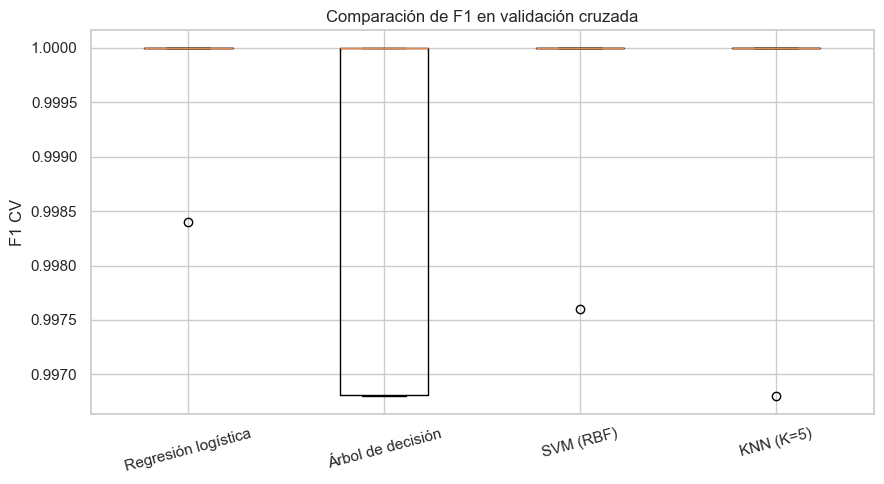

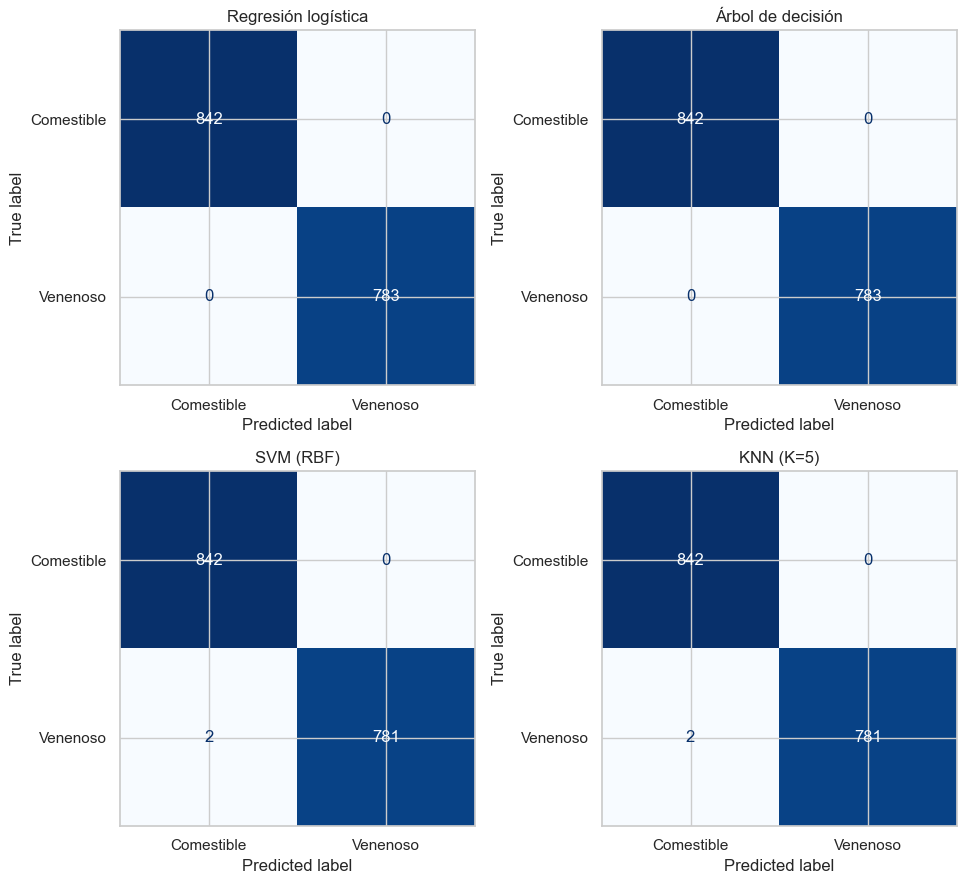

In [36]:
rows=[]
for name, pred in preds_m.items():
    rows.append({'Modelo':name,'F1 CV medio':scores_m[name].mean(),
        'Desv. estándar CV':scores_m[name].std(),
        'Accuracy test':accuracy_score(ym_test,pred),
        'Precision venenoso':__import__('sklearn.metrics').metrics.precision_score(
            ym_test,pred,zero_division=0),
        'Recall venenoso':__import__('sklearn.metrics').metrics.recall_score(
            ym_test,pred,zero_division=0),
        'F1 venenoso test':f1_score(ym_test,pred,zero_division=0)})
results_m=pd.DataFrame(rows).set_index('Modelo')
display(results_m.round(4))

fig,ax=plt.subplots(figsize=(9,5))
ax.boxplot([scores_m[n] for n in models_m],tick_labels=list(models_m))
ax.set_ylabel('F1 CV'); ax.set_title('Comparación de F1 en validación cruzada')
plt.xticks(rotation=15); plt.tight_layout(); plt.show()

fig,axes=plt.subplots(2,2,figsize=(10,9))
for ax,(name,pred) in zip(axes.flatten(),preds_m.items()):
    ConfusionMatrixDisplay.from_predictions(ym_test,pred,display_labels=[
        'Comestible','Venenoso'],ax=ax,cmap='Blues',colorbar=False)
    ax.set_title(name)
plt.tight_layout(); plt.show()

# Curvas ROC comparativas (probabilidades cuando el estimador las ofrece).
from sklearn.metrics import RocCurveDisplay
fig, ax = plt.subplots(figsize=(7, 6))
for name, model in models_m.items():
    if hasattr(model, 'predict_proba'):
        RocCurveDisplay.from_estimator(model, Xm_test, ym_test, ax=ax, name=name)
ax.plot([0,1],[0,1],'k--',alpha=0.6,label='Clasificador aleatorio')
ax.set_title('Curvas ROC — detección de hongos venenosos')
ax.legend(loc='lower right'); plt.tight_layout(); plt.show()


## 10. Hallazgos y conclusiones
Al ejecutar el notebook, la tabla y los gráficos permiten comparar rendimiento medio, variabilidad entre particiones y errores en test. Priorice la lectura del recall de la clase venenosa (cuántos venenosos detecta) junto con su precisión (cuántas predicciones de venenoso son correctas). Una matriz con falsos negativos para la clase venenosa representa hongos venenosos predichos como comestibles, un error especialmente relevante en este contexto. Registre aquí el modelo con sus métricas observadas y explique las confusiones que muestra su matriz; no declare un resultado numérico sin ejecutar el análisis.
**Limitación de uso:** este ejercicio es académico. Las predicciones no deben utilizarse para identificar hongos silvestres ni decidir si son seguros para el consumo.
